In [2]:
# Name: Jackson Irungu Maina
# Reg No: ST61/55297/2025
# Programme: ST61 - Master of Data Science
# School: School of Science and Technology
# Course: CSA 806 (Year 1 Sem 2 )
# Task: Module 7
# Assessment 2: Kenyan Health Statistics Clustering Project

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

In [5]:
# 1. LOAD DATA
# Ensure the file 'Malaria_Dataset.csv' is in the same directory as your notebook
try:
    df = pd.read_csv('malaria.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'Malaria_Dataset.csv' not found. Please check the file path.")

Dataset loaded successfully.


In [6]:
# 2. FEATURE SELECTION & PREPROCESSING
# Selecting clinical symptoms and risk scores for clustering
features = ['Age', 'Fever', 'Headache', 'Abdominal_Pain', 'General_Body_Malaise',
            'Dizziness', 'Vomiting', 'Confusion', 'Backache', 'Chest_Pain',
            'Coughing', 'Joint_Pain', 'Risk_Score']

X = df[features].copy()

# Feature Scaling: Essential for distance-based algorithms like Hierarchical Clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

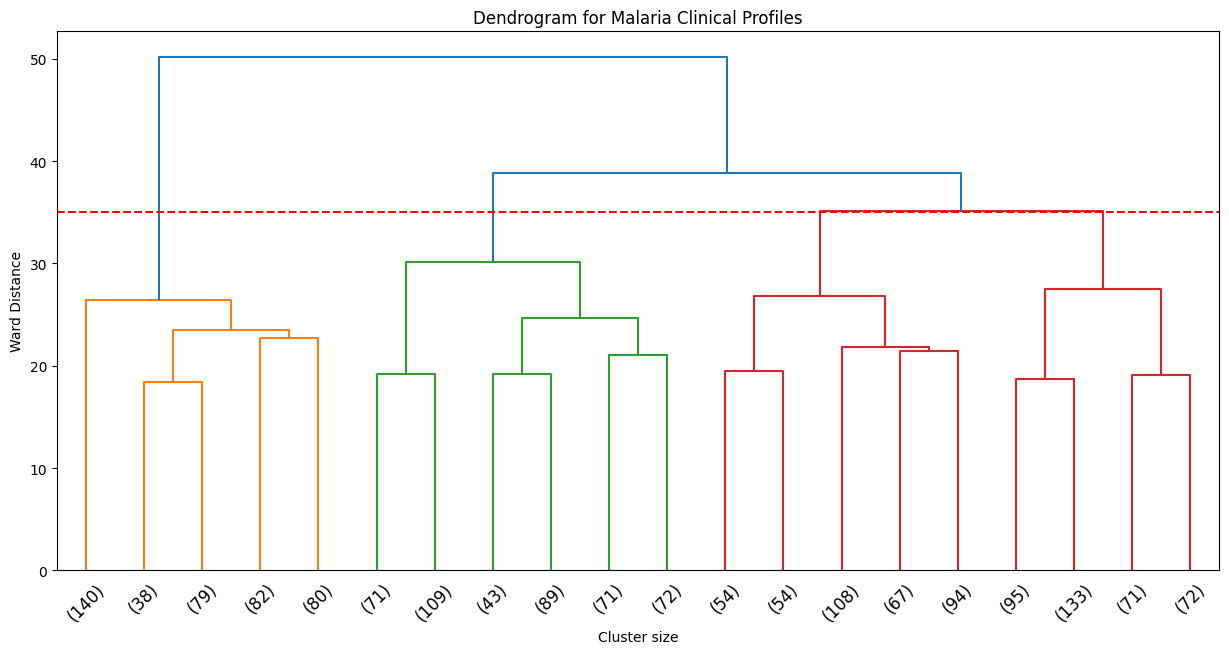

In [7]:
# 3. GENERATE DENDROGRAM (Hierarchy Visualization)
# We use 'Ward' linkage to minimize variance within clusters
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=45)
plt.title('Dendrogram for Malaria Clinical Profiles')
plt.xlabel('Cluster size')
plt.ylabel('Ward Distance')
plt.axhline(y=35, color='r', linestyle='--') # Visual guide for cluster cut-off
plt.show()

In [8]:
# 4. PERFORM AGGLOMERATIVE CLUSTERING
# Based on the dendrogram, we choose n_clusters=3
n_clusters = 3
cluster_model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
df['Cluster'] = cluster_model.fit_predict(X_scaled)

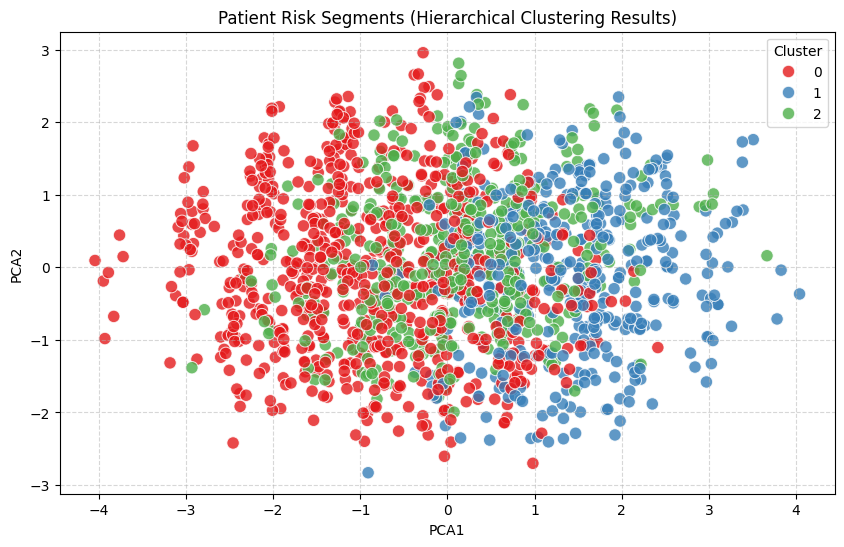

In [9]:
# 5. VISUALIZATION (Dimensionality Reduction using PCA)
# Reducing 13 features to 2 Principal Components for a 2D scatter plot
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)
df['PCA1'] = pca_results[:, 0]
df['PCA2'] = pca_results[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', s=80, alpha=0.8)
plt.title('Patient Risk Segments (Hierarchical Clustering Results)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [10]:
# 6. RESULTS INTERPRETATION
print("\n--- Cluster Centroids (Mean Values per Group) ---")
print(df.groupby('Cluster')[features].mean().round(2))

print("\n--- Distribution by Residence Area ---")
print(df.groupby(['Cluster', 'Residence_Area']).size().unstack(fill_value=0))


--- Cluster Centroids (Mean Values per Group) ---
           Age  Fever  Headache  Abdominal_Pain  General_Body_Malaise  \
Cluster                                                                 
0        47.75   0.16      0.44            0.43                  0.42   
1        37.29   0.66      0.56            0.68                  0.89   
2        46.52   0.82      0.57            0.45                  0.19   

         Dizziness  Vomiting  Confusion  Backache  Chest_Pain  Coughing  \
Cluster                                                                   
0             0.44      0.40       0.45      0.49        0.51      0.51   
1             0.57      0.69       0.48      0.52        0.48      0.51   
2             0.56      0.48       0.53      0.53        0.51      0.41   

         Joint_Pain  Risk_Score  
Cluster                          
0              0.55        6.54  
1              0.50       11.49  
2              0.46        8.63  

--- Distribution by Residence Area -